# Day 10 - PyTorch 入门 - 自动求导解放双手

> 目标: 从 numpy 手写过渡到 PyTorch, 理解 Tensor / Autograd / nn.Module
>
> Day 9 你手写了反向传播的 5 行核心代码, 今天 PyTorch 帮你自动算

---

## Day 9 vs Day 10

```
Day 9:  前向传播(手写) -> 反向传播(手写链式法则) -> W -= lr * dW(手写)
Day 10: 前向传播(手写) -> loss.backward()           -> optimizer.step()
                              ^^^^^^^^^^^               ^^^^^^^^^^^^^
                              自动求导!                  自动更新!
```

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # 解决 PyTorch + sklearn 的 OpenMP 冲突

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 10 - PyTorch')
print(f'PyTorch version: {torch.__version__}')
print('=' * 40)

Day 10 - PyTorch
PyTorch version: 2.13.0+cpu


## 1. Tensor - 就是 numpy 数组, 但能自动求导

> numpy array 和 torch Tensor 几乎一样, 关键区别: Tensor 有 requires_grad

| 操作 | NumPy | PyTorch |
|------|-------|---------|
| 创建全零 | np.zeros((3,4)) | torch.zeros(3,4) |
| 创建随机 | np.random.randn(3,4) | torch.randn(3,4) |
| 矩阵乘法 | a @ b | a @ b |
| 转置 | a.T | a.T |
| 求和 | a.sum() | a.sum() |
| 求梯度 | 手写反向传播 | loss.backward() |

In [22]:
# Tensor 基础操作: 和 numpy 几乎一模一样

# 创建 tensor
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.randn(2, 3)  # 标准正态分布随机数

print(f'a: shape={a.shape}')
print(a)
print(f'\nb: shape={b.shape}')
print(b)
print(f'\na @ b (矩阵乘法): shape={(a@b).shape}')
print(a @ b)

# Tensor <-> numpy 互转
a_np = a.numpy()           # tensor -> numpy
a_back = torch.from_numpy(a_np)  # numpy -> tensor
print(f'\ntensor->numpy: {type(a_np).__name__}')
print(f'numpy->tensor: {type(a_back).__name__}')

a: shape=torch.Size([2, 2])
tensor([[1., 2.],
        [3., 4.]])

b: shape=torch.Size([2, 3])
tensor([[-0.8031,  0.5768,  0.8602],
        [-1.0106, -0.4830,  0.7623]])

a @ b (矩阵乘法): shape=torch.Size([2, 3])
tensor([[-2.8243, -0.3892,  2.3848],
        [-6.4516, -0.2015,  5.6299]])

tensor->numpy: ndarray
numpy->tensor: Tensor


## 2. Autograd - 自动求导, 不用手写反向传播了!

> 这是 PyTorch 最核心的功能: 只要定义了前向计算, backward() 自动算出所有梯度

### 回忆 Day 9 手写反向传播有多麻烦

```python
# Day 9: 6 行手写梯度
dL_dz2 = y_pred - y
dL_dW2 = (dL_dz2.T @ h) / m
dL_dh  = dL_dz2 @ W2
dL_dz1 = dL_dh * relu_derivative(z1)
dL_dW1 = (dL_dz1.T @ X) / m
dL_db1 = dL_dz1.mean(0)
```

### Day 10: PyTorch 一行搞定

```python
loss.backward()  # 所有梯度自动算好!
print(W1.grad)   # dL/dW1 已经在里面了
```

### 原理: 计算图

```
PyTorch 在执行前向传播时, 暗中记录每一步操作, 构建"计算图"
当你调用 backward() 时, 沿着计算图反向传播, 自动用链式法则求导
```

In [25]:
# Autograd 简单演示: 和 Day 9 链式法则的例子对应

# y = (3x)^2, 求 x=2 时的 dy/dx
x = torch.tensor(2.0, requires_grad=True)  # requires_grad=True 告诉 PyTorch 要追踪这个变量

a = 3 * x          # a = 3x
b = a ** 2         # b = a^2

b.backward()       # 自动求导! 等价于手写 db/dx

print(f'x = {x.item()}')
print(f'a = {a.item()}, b = {b.item()}')
print(f'PyTorch 自动求导 db/dx = {x.grad.item()}')  # x.grad 就是 db/dx
print(f'解析解 = 18x = {18 * x.item()}')
print(f'一致! 不需要手写链式法则, PyTorch 自动帮你做了')

# 对比 Day 9:
# Day 9 写了 forward(x), backward(x), db_da * da_dx 三个函数
# Day 10 只需要: 定义计算 -> backward() -> x.grad

x = 2.0
a = 6.0, b = 36.0
PyTorch 自动求导 db/dx = 36.0
解析解 = 18x = 36.0
一致! 不需要手写链式法则, PyTorch 自动帮你做了


## 3. 用 PyTorch 重写 XOR 网络 (对比 Day 9)

> Day 9 手写了 50 行训练代码, Day 10 用 PyTorch 只需要一半

### 手写版 (Day 9) vs PyTorch 版 (Day 10)

| 步骤 | Day 9 (numpy 手写) | Day 10 (PyTorch) |
|------|-------------------|-----------------|
| 定义参数 | W1 = np.random.randn(3,2)*0.5 | nn.Linear(2, 3) |
| 前向传播 | h = relu(X @ W1.T + b1) | h = torch.relu(linear1(X)) |
| 损失函数 | 手写 binary_cross_entropy | nn.BCELoss() |
| 反向传播 | 6 行手写梯度 | loss.backward() |
| 更新参数 | W -= lr * dW | optimizer.step() |

In [28]:
# ============================================
# 方法1: 手动管理参数 (最接近 Day 9 的写法, 但用 autograd)
# ============================================

torch.manual_seed(42)

# 定义参数 (requires_grad=True 让 PyTorch 追踪梯度)
W1 = torch.randn(3, 2) * 0.5; W1.requires_grad = True
b1 = torch.zeros(3);            b1.requires_grad = True
W2 = torch.randn(1, 3) * 0.5;  W2.requires_grad = True
b2 = torch.zeros(1);            b2.requires_grad = True

# XOR 数据
X = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

lr = 0.5
losses_manual = []

for epoch in range(2000):
    # ==== 前向传播 (和 Day 9 完全一样) ====
    z1 = X @ W1.T + b1
    h = torch.relu(z1)
    z2 = h @ W2.T + b2
    y_pred = torch.sigmoid(z2)

    # 损失 (BCE 手写, 和 Day 9 一样)
    eps = 1e-15
    y_pred_clamped = torch.clamp(y_pred, eps, 1 - eps)
    loss = -(y * torch.log(y_pred_clamped) + (1 - y) * torch.log(1 - y_pred_clamped)).mean()

    losses_manual.append(loss.item())

    # ==== 反向传播 (PyTorch 自动! 不再需要手写 6 行) ====
    loss.backward()

    # ==== 梯度下降 (和 Day 9 一样, 但用 .grad 而不是手算的 dW) ====
    with torch.no_grad():  # 更新参数时不需要追踪梯度
        W1 -= lr * W1.grad; b1 -= lr * b1.grad
        W2 -= lr * W2.grad; b2 -= lr * b2.grad
        # 清零梯度 (重要! 否则会累加)
        W1.grad.zero_(); b1.grad.zero_()
        W2.grad.zero_(); b2.grad.zero_()

print(f'最终 loss: {losses_manual[-1]:.6f}')
print()
with torch.no_grad():
    for i in range(4):
        h_i = torch.relu(X[i] @ W1.T + b1)
        pred = torch.sigmoid(h_i @ W2.T + b2)
        print(f'  XOR({X[i][0]:.3f},{X[i][1]:.3f})={y[i][0]:.3f}  预测:{pred.item():.4f}')

最终 loss: 0.002073

  XOR(0.000,0.000)=0.000  预测:0.0058
  XOR(0.000,1.000)=1.000  预测:0.9991
  XOR(1.000,0.000)=1.000  预测:0.9991
  XOR(1.000,1.000)=0.000  预测:0.0007


In [29]:
# ============================================
# 方法2: 用 nn.Module + optimizer (标准 PyTorch 写法)
# ============================================

# 定义一个 MLP 类, 继承 nn.Module
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 3)   # 输入2 -> 隐藏3   (代替手写 W1, b1)
        self.fc2 = nn.Linear(3, 1)   # 隐藏3 -> 输出1   (代替手写 W2, b2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # 隐藏层: 线性 + ReLU
        x = torch.sigmoid(self.fc2(x))  # 输出层: 线性 + Sigmoid
        return x

torch.manual_seed(42)
model = SimpleMLP()
criterion = nn.BCELoss()              # 二分类交叉熵 (不用手写了!)
optimizer = optim.SGD(model.parameters(), lr=0.5)  # SGD 优化器 (不用手写更新了!)

X = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

losses_module = []

for epoch in range(2000):
    # ==== 前向传播 ====
    y_pred = model(X)

    # ==== 损失 ====
    loss = criterion(y_pred, y)
    losses_module.append(loss.item())

    # ==== 反向传播 + 更新 (两行搞定!) ====
    optimizer.zero_grad()  # 清零梯度 (对应 Day 9 里 .grad.zero_())
    loss.backward()        # 自动求导 (对应 Day 9 里 6 行手写梯度)
    optimizer.step()       # 更新参数 (对应 Day 9 里 W -= lr * dW)

print(f'最终 loss: {losses_module[-1]:.6f}')
print()
with torch.no_grad():
    pred = model(X)
    for i in range(4):
        print(f'  XOR({X[i][0]:.0f},{X[i][1]:.0f})={y[i][0]:.0f}  预测:{pred[i].item():.4f}')

最终 loss: 0.000698

  XOR(0,0)=0  预测:0.0008
  XOR(0,1)=1  预测:0.9993
  XOR(1,0)=1  预测:0.9993
  XOR(1,1)=0  预测:0.0005


d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site

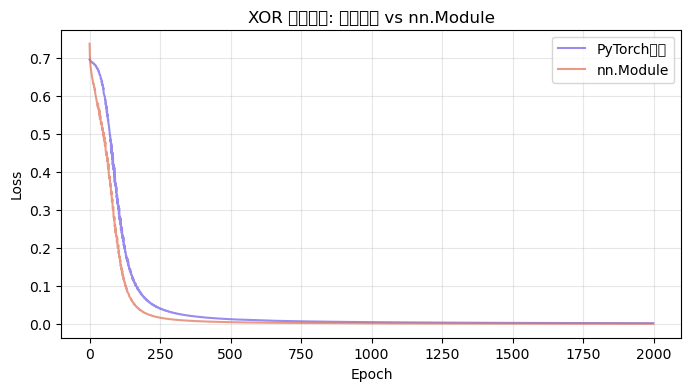

In [30]:
# 对比三版训练的损失曲线
plt.figure(figsize=(8, 4))
plt.plot(losses_manual, color='#6c5ce7', linewidth=1.5, alpha=0.7, label='PyTorch手动')
plt.plot(losses_module, color='#e17055', linewidth=1.5, alpha=0.7, label='nn.Module')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('XOR 训练曲线: 手动管理 vs nn.Module')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## 4. PyTorch 训练模板 (背下来)

> 以后所有 PyTorch 项目都是这个结构

```python
# 1. 定义模型
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = self.layer2(x)  # 输出层
        return x

model = MyModel()

# 2. 定义损失函数和优化器
criterion = nn.MSELoss()        # 回归用 MSE
# criterion = nn.BCELoss()      # 二分类用 BCE
# criterion = nn.CrossEntropyLoss()  # 多分类用交叉熵
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 比 SGD 更好

# 3. 训练循环 (这个结构永远不变!)
for epoch in range(epochs):
    y_pred = model(X_train)         # 前向
    loss = criterion(y_pred, y_train)  # 算损失

    optimizer.zero_grad()           # 清零梯度
    loss.backward()                 # 反向传播
    optimizer.step()                # 更新参数
```

### Day 9 vs Day 10 代码量对比

```
Day 9 (numpy):  定义激活函数(6行) + 损失(4行) + 前向(5行) + 反向(7行) + 更新(5行) = ~27行核心
Day 10 (torch): nn.Module(8行) + criterion(1行) + optimizer(1行) + 训练循环(5行) = ~15行核心
```

## 5. 用 PyTorch 在乳腺癌数据上跑 MLP

> Day 8 用 sklearn.MLPClassifier 跑过, 现在用 PyTorch 重写


PyTorch MLP 测试准确率: 0.9737
对比 Day 8 sklearn MLPClassifier: ~0.97


d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20083 (\N{CJK UNIFIED IDEOGRAPH-4E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33146 (\N{CJK UNIFIED IDEOGRAPH-817A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30284 (\N{CJK UNIFIED IDEOGRAPH-764C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site

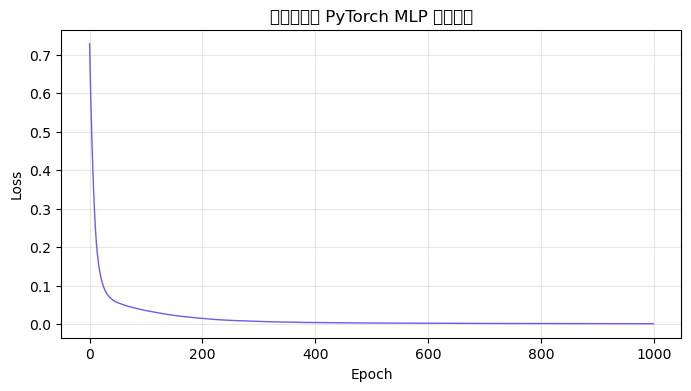

In [31]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 准备数据
data = load_breast_cancer()
X_np, y_np = data.data.astype(np.float32), data.target.astype(np.float32).reshape(-1, 1)
X_np = StandardScaler().fit_transform(X_np)
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42)

# 转 PyTorch tensor
X_train = torch.from_numpy(X_train_np)
y_train = torch.from_numpy(y_train_np)
X_test = torch.from_numpy(X_test_np)
y_test = torch.from_numpy(y_test_np)

# 定义 MLP
class BreastCancerMLP(nn.Module):
    def __init__(self, input_dim=30, hidden_dim=16, output_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

torch.manual_seed(42)
model = BreastCancerMLP(hidden_dim=16)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 训练
losses = []
for epoch in range(1000):
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 评估
with torch.no_grad():
    y_test_pred = model(X_test)
    y_test_label = (y_test_pred > 0.5).float()
    acc = (y_test_label == y_test).float().mean()

print(f'PyTorch MLP 测试准确率: {acc.item():.4f}')
print(f'对比 Day 8 sklearn MLPClassifier: ~0.97')

plt.figure(figsize=(8, 4))
plt.plot(losses, color='#6c5ce7', linewidth=1)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('乳腺癌数据 PyTorch MLP 训练曲线')
plt.grid(True, alpha=0.3)
plt.show()

---

# Day 10 完成！

## 今天学到了什么

| 概念 | 一句话 |
|------|--------|
| **Tensor** | numpy 数组的 PyTorch 版, 多了 requires_grad |
| **Autograd** | `loss.backward()` 自动算所有梯度, 不再手写链式法则 |
| **nn.Module** | 封装参数和 forward, 像搭积木一样搭网络 |
| **nn.Linear** | 代替手写 W 和 b: `nn.Linear(in_dim, out_dim)` |
| **optimizer** | 代替手写 W -= lr*dW: `optimizer.step()` |
| **训练模板** | define model -> criterion + optimizer -> train loop |

## 对比三天的演进

| | Day 8 | Day 9 | Day 10 |
|------|-------|-------|--------|
| **工具** | sklearn | numpy | PyTorch |
| **前向** | sklearn内部 | 手写 | 手写或nn.Module |
| **反向** | sklearn内部 | 6行手写 | loss.backward() |
| **更新** | sklearn内部 | 4行手写 | optimizer.step() |
| **代码量** | 3行 | ~30行 | ~15行 |

## 晚上作业

1. 把乳腺癌 MLP 的 hidden_dim 从 16 改成 64, 准确率有提升吗?  没有
2. 把优化器从 Adam 改成 SGD, 观察收敛速度差异 
核心改动与注意事项：
优化器替换：
# 原来： optimizer = optim.Adam(model.parameters(), lr=0.01)
# 现在：optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
为什么加了 momentum=0.9？
普通的 SGD 容易在损失函数的“山谷”里来回震荡，或者卡在局部极小值出不来。加上动量（Momentum）相当于给小球加惯性，能让优化过程更平滑、收敛更快。
学习率的敏感性：
Adam 对 lr=0.01 甚至 lr=0.001 都有很强的适应性。但 SGD 非常依赖学习率：
如果 Loss 曲线剧烈震荡不下降，说明 lr 太大了，可以尝试改成 lr=0.001。
如果 Loss 下降极慢，可以尝试稍微调大一点 lr。